# Analisis Tren Pasar Berdasarkan Berita Ekonomi CNBC Indonesia

Notebook ini digunakan untuk tahap awal proyek UAS Artificial Intelligence pada topik **Analisis Tren Pasar Berdasarkan Berita Ekonomi**. Dataset yang digunakan berasal dari Kaggle, yaitu *CNBC Indonesia Stock News Sentiment Dataset*. Dataset ini berisi judul berita pasar saham CNBC Indonesia periode Januari 2024 sampai Maret 2025.

Masalah yang ingin dibantu oleh proyek ini adalah banyaknya berita ekonomi dan pasar saham yang muncul setiap hari. Jika dibaca secara manual, proses memahami sentimen pasar akan memakan waktu. Dengan bantuan NLP, judul berita dapat dianalisis untuk mengetahui apakah kecenderungannya **positif**, **negatif**, atau **netral**.

Pada tahap ini, notebook fokus pada eksplorasi data awal atau EDA. Tujuannya adalah memahami bentuk dataset sebelum data dipakai untuk proses modeling, seperti TF-IDF dan klasifikasi sentimen.

Sumber dataset: https://www.kaggle.com/datasets/triagungj/cnbc-indonesia-stock-news-sentiment-dataset

## 1. Load Dataset dan Melihat Struktur Data

Pada bagian ini, library yang dibutuhkan diimport terlebih dahulu. Dataset kemudian dibaca menggunakan `pandas`.

Dataset memiliki 3 kolom utama:

- `judul`: judul berita dari CNBC Indonesia.
- `tanggal`: tanggal publikasi berita.
- `sentimen`: label sentimen berita, yaitu positif, negatif, atau netral.

Langkah ini penting karena sebelum membuat model AI, kita harus memastikan data yang digunakan sudah terbaca dengan benar dan kolomnya sesuai kebutuhan analisis.


In [19]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

data_path = Path("data/Dataset-CNBCI-Sentimented.csv")
if not data_path.exists():
    data_path = Path("../../data/Dataset-CNBCI-Sentimented.csv")

df = pd.read_csv(data_path)

display(df.head())
print("Daftar kolom di dataset ini:", df.columns.tolist())


,judul,tanggal,sentimen
0,"Direktur Garuda Salman El Farisiy Meninggal, I...",2024/01/01,negatif
1,"Catatan Sejarah 2023, Indonesia Luncurkan Burs...",2024/01/01,netral
2,"Ramalan Bitcoin Paling Gila 2024, Naik 1.000% ...",2024/01/01,netral
3,Wah! Segini Harta Mantan Istri Prabowo Titiek ...,2024/01/01,netral
4,"Pensiun di Oktober 2024, Jokowi Kantongi Uang ...",2024/01/01,netral


Daftar kolom di dataset ini: ['judul', 'tanggal', 'sentimen']


## 2. Pengecekan Integritas Data

**Analisis Integritas Data:**
Tujuan utama pembersihan awal ini adalah untuk memvalidasi kualitas dataset mentah sebelum masuk ke *pipeline* NLP. Ketiadaan *missing values* dan data duplikat sangat krusial; *noise* pada tahap ini dapat mendistorsi pembobotan frekuensi kata pada matriks TF-IDF nantinya, yang berujung pada metrik evaluasi yang bias.

In [16]:
print("=== Pengecekan Data Kosong (Missing Values) ===")
print(df.isnull().sum())

print("\n=== Pengecekan Data Duplikat ===")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    df = df.drop_duplicates()
    print("Data duplikat berhasil dihapus!")


=== Pengecekan Data Kosong (Missing Values) ===
judul       0
tanggal     0
sentimen    0
dtype: int64

=== Pengecekan Data Duplikat ===
Jumlah baris duplikat: 3
Data duplikat berhasil dihapus!


### Interpretasi Hasil

Hasil pengecekan menunjukkan bahwa semua kolom memiliki nilai kosong sebanyak 0. Artinya, dataset tidak membutuhkan penghapusan baris karena missing value.

Namun, ditemukan 3 baris duplikat. Duplikat ini dihapus agar data yang sama tidak dihitung lebih dari satu kali. Langkah ini penting karena data duplikat bisa membuat analisis dan model menjadi bias.


## 3. Visualisasi Distribusi Kelas Sentimen

**Analisis Distribusi Kelas:**
Visualisasi ini berfungsi sebagai indikator awal adanya *class imbalance* (ketidakseimbangan kelas) pada data sentimen berita ekonomi. Mengetahui proporsi kelas positif, negatif, dan netral secara kuantitatif mendasari keputusan teknis selanjutnya, yaitu pewajiban penggunaan parameter `stratify` saat *data splitting*. Hal ini memastikan model tidak mengalami kondisi *overfitting* atau bias terhadap kelas mayoritas saat fase pelatihan.

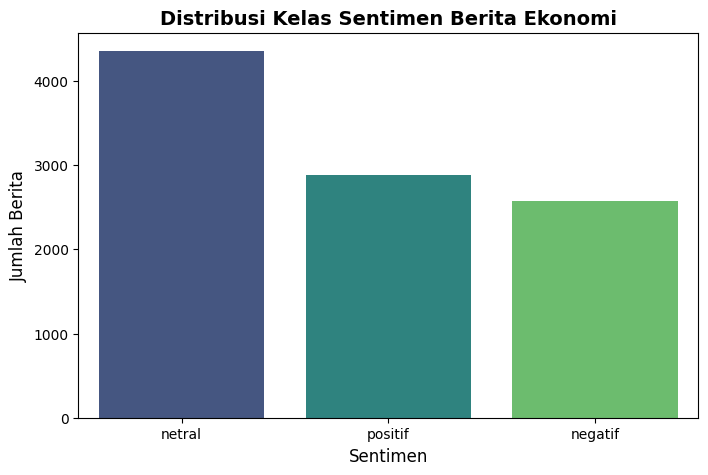

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentimen', hue='sentimen', palette='viridis', order=df['sentimen'].value_counts().index, legend=False)
plt.title('Distribusi Kelas Sentimen Berita Ekonomi', fontsize=14, fontweight='bold')
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah Berita', fontsize=12)
plt.show()


### Interpretasi Hasil

Grafik distribusi sentimen menunjukkan bahwa kelas `netral` memiliki jumlah data paling banyak, kemudian diikuti `positif` dan `negatif`.

Setelah duplikat dihapus, jumlah datanya adalah 4.354 netral, 2.887 positif, dan 2.575 negatif. Perbedaan jumlah antar kelas masih terlihat wajar, tetapi kelas netral tetap lebih dominan. Pada tahap modeling, kondisi ini perlu diperhatikan karena model bisa cenderung lebih mudah memprediksi kelas yang jumlahnya paling banyak.


## 4. Analisis Panjang Teks dan Jumlah Kata
Mengetahui distribusi panjang karakter dan kata membantu menentukan kompleksitas arsitektur model NLP yang dibutuhkan.

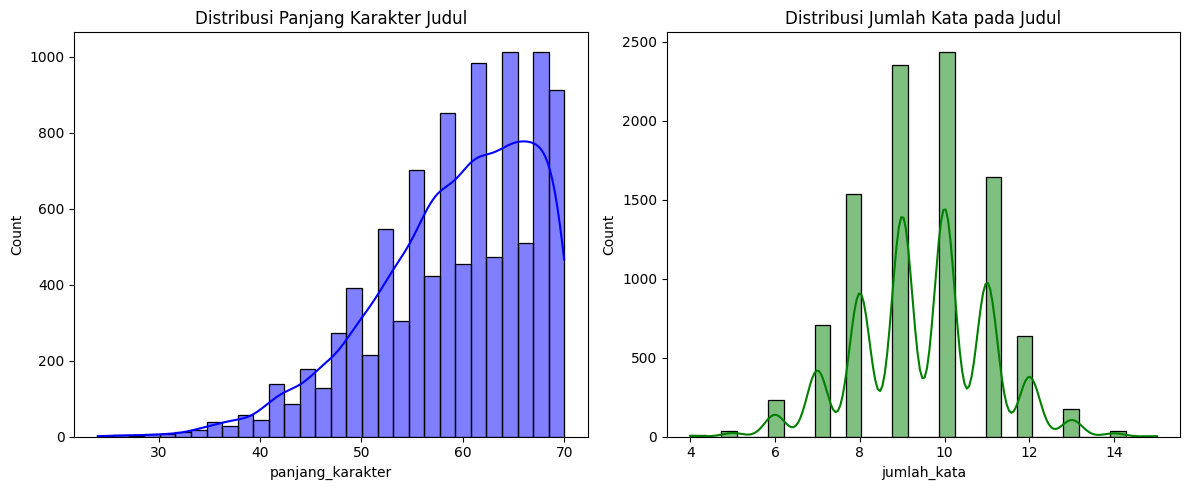

In [18]:
df['panjang_karakter'] = df['judul'].apply(len)
df['jumlah_kata'] = df['judul'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['panjang_karakter'], bins=30, kde=True, color='blue')
plt.title('Distribusi Panjang Karakter Judul')

plt.subplot(1, 2, 2)
sns.histplot(df['jumlah_kata'], bins=30, kde=True, color='green')
plt.title('Distribusi Jumlah Kata pada Judul')

plt.tight_layout()
plt.show()


### Interpretasi Hasil

Histogram panjang karakter dan jumlah kata menunjukkan bahwa mayoritas judul berita memiliki ukuran yang relatif singkat. Rata-rata judul memiliki sekitar 59 karakter dan sekitar 9 kata.

Hal ini sesuai karena data yang digunakan adalah judul berita, bukan isi artikel lengkap. Karena teksnya pendek, teknik seperti TF-IDF dapat digunakan untuk mengambil kata penting dari judul, lalu hasilnya dipakai sebagai fitur untuk model klasifikasi.


## 5. Word Cloud Berita Ekonomi
Visualisasi frekuensi kata yang paling sering muncul untuk memahami topik utama dalam dataset.

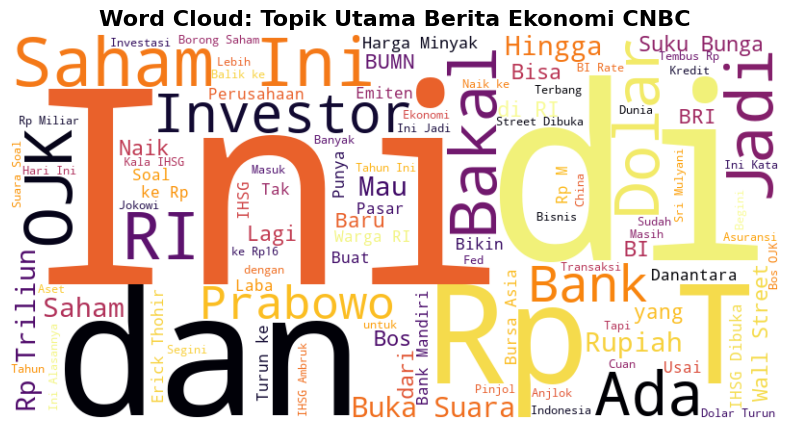

In [ ]:
semua_teks = ' '.join(df['judul'].dropna().astype(str).tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno', max_words=100).generate(semua_teks)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Topik Utama Berita Ekonomi CNBC', fontsize=16, fontweight='bold')
plt.show()


### Interpretasi Hasil

Word cloud menampilkan kata-kata yang paling sering muncul pada judul berita. Kata yang tampil lebih besar berarti lebih sering muncul di dataset.

Dari visualisasi ini, kita dapat memahami gambaran umum topik berita yang sering muncul, seperti isu pasar, saham, ekonomi, perusahaan, atau investasi. Word cloud bukan hasil model, tetapi membantu tahap EDA untuk mengenali pola kata sebelum dilakukan preprocessing dan modeling.


## Ringkasan EDA

Berdasarkan eksplorasi awal, dataset CNBC Indonesia Stock News Sentiment memiliki 9.819 data awal. Setelah 3 baris duplikat dihapus, data yang digunakan menjadi 9.816 baris dan tidak memiliki missing value. Kondisi ini membuat data lebih siap digunakan untuk tahap modeling.

Mayoritas berita berada pada kelas netral, diikuti positif dan negatif. Hal ini sesuai dengan karakter berita ekonomi yang sering bersifat informatif. Panjang judul juga relatif singkat, sehingga pendekatan NLP seperti TF-IDF cocok digunakan untuk mengubah teks menjadi fitur numerik.

Tahap EDA ini menjadi dasar sebelum membangun sistem AI end-to-end, misalnya aplikasi Streamlit yang menerima input judul berita, melakukan preprocessing, menjalankan model klasifikasi, lalu menampilkan hasil sentimen kepada pengguna. Pada tahap evaluasi model, metrik yang perlu ditampilkan adalah Accuracy, Precision, Recall, dan F1-Score agar performa model dapat dinilai secara transparan.

Referensi utama:

- Kaggle: CNBC Indonesia Stock News Sentiment Dataset.
- Scikit-learn Documentation: TF-IDF, SVM, dan classification metrics.
- WordCloud Python Documentation untuk visualisasi kata.
